# When Weather Changes the City
## Wrangling NYC 311 service requests with Central Park weather data

New York changes with the weather. Calls to 311 change too. This analysis uses three years of service request data and daily NOAA weather data. It shows how cold, heat, and rain change complaints across the five boroughs.

## Analysis map

1. Collect NYC service requests and Central Park weather observations
2. Inspect the values and table structure
3. Clean the fields and combine the daily records
4. Explore how complaints change with weather
5. Note the limits and possible next steps

In [1]:
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

RAW_DIR = Path("data/raw")
CLEAN_DIR = Path("data/cleaned")
FIGURES_DIR = Path("figures")
for directory in (RAW_DIR, CLEAN_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ANALYSIS_START = "2022-01-01"
ANALYSIS_END = "2024-12-31"

## 1. Gather data

### 1.1 Question

The question I wanted to answer is simple. How do temperature and rain affect NYC 311 complaints? Do all boroughs respond in the same way? The analysis combines NYC Open Data counts with NOAA observations from Central Park for 2022 to 2024. It focuses on heat and hot water, street noise, street conditions, sewer problems, and air quality.

### 1.2 Dataset 1: NYC 311 Service Requests

**Type:** CSV returned by a public API  
**Method:** API access through the NYC Open Data Socrata endpoint  
**Source:** [311 Service Requests from 2010 to Present](https://data.cityofnewyork.us/resource/erm2-nwe9)

NYC 311 records the problems that residents report. This makes it a useful measure of service demand. The API returns daily counts for a fixed three year window. `request_date` is the day of the request. `complaint_type` names the issue. `borough` gives the location. `request_count` gives the number of requests in each group.

In [2]:
# The API query is kept here so the gathering process is fully reproducible.
NYC_API_URL = "https://data.cityofnewyork.us/resource/erm2-nwe9.csv"
NYC_RAW_PATH = RAW_DIR / "nyc_311_weather_complaints_2022_2024_raw.csv"
COMPLAINT_TYPES = [
    "HEAT/HOT WATER",
    "Noise - Street/Sidewalk",
    "Street Condition",
    "Sewer",
    "Air Quality",
]


def gather_311_data():
    frames = []
    quoted_types = ", ".join(f"'{value}'" for value in COMPLAINT_TYPES)

    for year in (2022, 2023, 2024):
        params = {
            "$select": (
                "date_trunc_ymd(created_date) as request_date, "
                "complaint_type, borough, count(*) as request_count"
            ),
            "$where": (
                f"created_date >= '{year}-01-01T00:00:00.000' AND "
                f"created_date < '{year + 1}-01-01T00:00:00.000' AND "
                f"complaint_type IN ({quoted_types})"
            ),
            "$group": "date_trunc_ymd(created_date), complaint_type, borough",
            "$order": "request_date, complaint_type, borough",
            "$limit": 50000,
        }
        response = requests.get(NYC_API_URL, params=params, timeout=180)
        response.raise_for_status()
        frames.append(pd.read_csv(BytesIO(response.content)))

    result = pd.concat(frames, ignore_index=True)
    result.to_csv(NYC_RAW_PATH, index=False)
    return result


if NYC_RAW_PATH.exists():
    service_requests = pd.read_csv(NYC_RAW_PATH)
    gathering_status = "Loaded the stored raw API result"
else:
    service_requests = gather_311_data()
    gathering_status = "Downloaded fresh data from the NYC Open Data API"

print(gathering_status)
print(f"Rows: {len(service_requests):,} | Columns: {service_requests.shape[1]}")
service_requests.head()

Loaded the stored raw API result
Rows: 26,631 | Columns: 4


,request_date,complaint_type,borough,request_count
0,2022-01-01T00:00:00.000,Air Quality,MANHATTAN,5
1,2022-01-01T00:00:00.000,Air Quality,QUEENS,2
2,2022-01-01T00:00:00.000,HEAT/HOT WATER,BRONX,164
3,2022-01-01T00:00:00.000,HEAT/HOT WATER,BROOKLYN,114
4,2022-01-01T00:00:00.000,HEAT/HOT WATER,MANHATTAN,114


### Dataset 2: NOAA Central Park Daily Weather

**Type:** CSV file  
**Method:** Manual file download  
**Source:** [NOAA GHCN Daily station USW00094728](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/USW00094728.csv)

Central Park has a long official weather record from inside NYC. The analysis uses `DATE`, rain (`PRCP`), snow (`SNOW`), maximum temperature (`TMAX`), minimum temperature (`TMIN`), and NOAA flags. The file covers daily weather from 1869 onward.

In [3]:
WEATHER_RAW_PATH = RAW_DIR / "central_park_weather_daily_raw.csv"
if not WEATHER_RAW_PATH.exists():
    raise FileNotFoundError(
        "Download the NOAA Central Park CSV from the source link above and save it as "
        f"{WEATHER_RAW_PATH}."
    )

weather = pd.read_csv(WEATHER_RAW_PATH, low_memory=False)
print(f"Rows: {len(weather):,} | Columns: {weather.shape[1]}")
print(f"Coverage: {weather['DATE'].min()} to {weather['DATE'].max()}")
weather[["STATION", "DATE", "PRCP", "PRCP_ATTRIBUTES", "SNOW", "TMAX", "TMIN"]].head()

Rows: 57,540 | Columns: 124
Coverage: 1869-01-01 to 2026-07-16


,STATION,DATE,PRCP,PRCP_ATTRIBUTES,SNOW,TMAX,TMIN
0,USW00094728,1869-01-01,191,",,Z,",229.00,-17.00,-72.00
1,USW00094728,1869-01-02,8,",,Z,null",0.00,-28.00,-61.00
2,USW00094728,1869-01-03,0,"T,,Z,null",0.00,17.00,-28.00
3,USW00094728,1869-01-04,46,",,Z,null",0.00,28.00,11.00
4,USW00094728,1869-01-05,13,",,Z,null",0.00,61.00,28.00


The API extract contains 26,631 daily borough and complaint records. The NOAA file contains more than a century of daily weather records. Both original files stay unchanged in `data/raw`.

In [4]:
dataset_inventory = pd.DataFrame(
    {
        "dataset": ["NYC 311", "NOAA Central Park weather"],
        "rows": [len(service_requests), len(weather)],
        "columns": [service_requests.shape[1], weather.shape[1]],
        "gathering_method": ["API access", "Manual CSV download"],
    }
)
dataset_inventory

,dataset,rows,columns,gathering_method
0,NYC 311,26631,4,API access
1,NOAA Central Park weather,57540,124,Manual CSV download


## 2. Assess data

Visual checks reveal the problems. Code checks measure them. The assessment focuses on borough labels, trace rain, packed NOAA flags, and the shared date key.

### Quality issue 1: Unspecified boroughs in the 311 data

Because one part of the question compares boroughs, rows labeled `Unspecified` cannot be assigned to a valid borough. Looking at examples confirms the label is present, while a frequency check measures how much data it affects.

In [5]:
# Visual assessment
service_requests.loc[
    service_requests["borough"].eq("Unspecified"),
    ["request_date", "complaint_type", "borough", "request_count"],
].head(8)

,request_date,complaint_type,borough,request_count
63,2022-01-03T00:00:00.000,Sewer,Unspecified,1
91,2022-01-04T00:00:00.000,Street Condition,Unspecified,1
158,2022-01-07T00:00:00.000,Sewer,Unspecified,1
283,2022-01-12T00:00:00.000,Street Condition,Unspecified,1
331,2022-01-14T00:00:00.000,Street Condition,Unspecified,1
399,2022-01-17T00:00:00.000,Sewer,Unspecified,1
405,2022-01-17T00:00:00.000,Street Condition,Unspecified,1
425,2022-01-18T00:00:00.000,Sewer,Unspecified,1


In [6]:
# Programmatic assessment
borough_check = service_requests["borough"].value_counts(dropna=False).rename("rows")
display(borough_check.to_frame())
unspecified_rows = service_requests["borough"].eq("Unspecified").sum()
print(f"Unspecified rows: {unspecified_rows:,} ({unspecified_rows / len(service_requests):.2%})")

,rows
borough,
BROOKLYN,5463
QUEENS,5459
MANHATTAN,5424
BRONX,5241
STATEN ISLAND,4689
Unspecified,355


Unspecified rows: 355 (1.33%)


**Finding:** `Unspecified` is not a valid borough for this comparison. A frequency count finds 355 affected rows. These rows cannot be assigned to a borough with confidence.

### Quality issue 2: Trace precipitation is recorded as zero

NOAA uses `T` when rain was detected but was too small to measure. A value of zero would mark these days as dry. That would hide the trace rain.

In [7]:
# Visual assessment: zero-valued precipitation with a trace flag
trace_weather = weather.loc[
    weather["PRCP_ATTRIBUTES"].str.startswith("T", na=False),
    ["DATE", "PRCP", "PRCP_ATTRIBUTES", "TMAX", "TMIN"],
]
trace_weather.head(8)

,DATE,PRCP,PRCP_ATTRIBUTES,TMAX,TMIN
2,1869-01-03,0,"T,,Z,null",17.00,-28.00
10,1869-01-11,0,"T,,Z,null",6.00,-11.00
16,1869-01-17,0,"T,,Z,null",17.00,-17.00
17,1869-01-18,0,"T,,Z,null",-17.00,-33.00
19,1869-01-20,0,"T,,Z,null",28.00,-11.00
28,1869-01-29,0,"T,,Z,null",89.00,-11.00
33,1869-02-03,0,"T,,Z,null",22.00,17.00
35,1869-02-05,0,"T,,Z,null",-33.00,-56.00


In [8]:
# Programmatic assessment within the analysis window
weather_dates = pd.to_datetime(weather["DATE"])
analysis_weather_mask = weather_dates.between(ANALYSIS_START, ANALYSIS_END)
trace_mask = weather["PRCP_ATTRIBUTES"].str.startswith("T", na=False)
print(f"Trace-precipitation days: {(analysis_weather_mask & trace_mask).sum():,}")
print("Raw PRCP values on those days:")
display(weather.loc[analysis_weather_mask & trace_mask, "PRCP"].value_counts().to_frame())

Trace-precipitation days: 118
Raw PRCP values on those days:


,count
PRCP,
0,118


**Finding:** The number and the flag do not mean the same thing. Zero means dry. `T` means that rain occurred. A check of both fields finds 118 trace rain days.

### Tidiness issue 1: NOAA attributes combine four variables in one column

`PRCP_ATTRIBUTES` contains four values separated by commas. They describe the measurement flag, quality flag, source flag, and observation time. Keeping them in one field makes each value harder to inspect and use.

In [9]:
# Visual assessment
weather.loc[analysis_weather_mask, ["DATE", "PRCP", "PRCP_ATTRIBUTES"]].head(10)

,DATE,PRCP,PRCP_ATTRIBUTES
55882,2022-01-01,201,",,W,2400"
55883,2022-01-02,10,",,W,2400"
55884,2022-01-03,0,",,W,2400"
55885,2022-01-04,0,",,W,2400"
55886,2022-01-05,58,",,W,2400"
55887,2022-01-06,0,",,W,2400"
55888,2022-01-07,97,",,W,2400"
55889,2022-01-08,0,",,W,2400"
55890,2022-01-09,25,",,W,2400"
55891,2022-01-10,0,",,W,2400"


In [10]:
# Programmatic assessment
attribute_parts = weather.loc[analysis_weather_mask, "PRCP_ATTRIBUTES"].str.split(",", expand=True)
print(f"Components found: {attribute_parts.shape[1]}")
attribute_parts.columns = ["measurement_flag", "quality_flag", "source_flag", "observation_time"]
attribute_parts.head()

Components found: 4


,measurement_flag,quality_flag,source_flag,observation_time
55882,,,W,2400
55883,,,W,2400
55884,,,W,2400
55885,,,W,2400
55886,,,W,2400


**Finding:** A split check finds four positions in every row. The fields can be separated in the same way across the full weather table.

### Tidiness issue 2: One daily observation is split across two tables

The complaint counts and weather measurements describe the same city day. They live in separate datasets. A shared date key is needed. A many to one merge gives each complaint group one weather record.

In [11]:
# Visual assessment
display(service_requests[["request_date", "complaint_type", "borough", "request_count"]].head(3))
display(weather.loc[analysis_weather_mask, ["DATE", "PRCP", "TMAX", "TMIN"]].head(3))

,request_date,complaint_type,borough,request_count
0,2022-01-01T00:00:00.000,Air Quality,MANHATTAN,5
1,2022-01-01T00:00:00.000,Air Quality,QUEENS,2
2,2022-01-01T00:00:00.000,HEAT/HOT WATER,BRONX,164


,DATE,PRCP,TMAX,TMIN
55882,2022-01-01,201,133.00,100.00
55883,2022-01-02,10,150.00,28.00
55884,2022-01-03,0,28.00,-55.00


In [12]:
# Programmatic assessment
service_dates = pd.to_datetime(service_requests["request_date"]).dt.normalize()
weather_analysis_dates = pd.to_datetime(weather.loc[analysis_weather_mask, "DATE"])
print(f"311 unique dates: {service_dates.nunique():,}")
print(f"Weather unique dates: {weather_analysis_dates.nunique():,}")
print(f"Overlapping dates: {len(set(service_dates) & set(weather_analysis_dates)):,}")
print(f"Duplicate weather dates: {weather_analysis_dates.duplicated().sum():,}")

311 unique dates: 1,096
Weather unique dates: 1,096
Overlapping dates: 1,096
Duplicate weather dates: 0


**Finding:** All 1,096 dates appear in both tables. NOAA has one record for each date. The tables can be joined without copying weather records.

## 3. Clean data

Cleaning starts from copies so the raw dataframes remain unchanged. Each step is followed by a direct validation.

In [13]:
service_clean = service_requests.copy()
weather_clean = weather.loc[analysis_weather_mask].copy()

print("Raw copies retained:")
print(f"service_requests: {service_requests.shape} | service_clean: {service_clean.shape}")
print(f"weather: {weather.shape} | weather_clean analysis window: {weather_clean.shape}")

Raw copies retained:
service_requests: (26631, 4) | service_clean: (26631, 4)
weather: (57540, 124) | weather_clean analysis window: (1096, 124)


### Remove unspecified borough rows

These rows are removed rather than assigned a guessed location. They cannot support the borough comparison, and filling them from complaint type or date would manufacture information.

In [14]:
before_borough_cleaning = len(service_clean)
service_clean = service_clean.loc[service_clean["borough"].ne("Unspecified")].copy()
removed_borough_rows = before_borough_cleaning - len(service_clean)
print(f"Removed {removed_borough_rows:,} rows")

Removed 355 rows


In [15]:
# Validation
assert not service_clean["borough"].eq("Unspecified").any()
print("Remaining boroughs:", sorted(service_clean["borough"].unique()))

Remaining boroughs: ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']


### Preserve trace precipitation

NOAA stores rain in tenths of a millimeter. The values are converted to millimeters. Trace rain becomes `0.05 mm`. This keeps trace days separate from dry days without adding too much rain.

In [16]:
weather_clean["prcp_mm"] = pd.to_numeric(weather_clean["PRCP"]) / 10
analysis_trace_mask = weather_clean["PRCP_ATTRIBUTES"].str.startswith("T", na=False)
weather_clean.loc[analysis_trace_mask, "prcp_mm"] = 0.05

In [17]:
# Validation
assert weather_clean.loc[analysis_trace_mask, "prcp_mm"].eq(0.05).all()
print(f"Corrected trace days: {analysis_trace_mask.sum():,}")
display(weather_clean.loc[analysis_trace_mask, ["DATE", "PRCP", "PRCP_ATTRIBUTES", "prcp_mm"]].head())

Corrected trace days: 118


,DATE,PRCP,PRCP_ATTRIBUTES,prcp_mm
55892,2022-01-11,0,"T,,W,2400",0.05
55905,2022-01-24,0,"T,,W,2400",0.05
55931,2022-02-19,0,"T,,W,2400",0.05
55953,2022-03-13,0,"T,,W,2400",0.05
55955,2022-03-15,0,"T,,W,2400",0.05


### Split the precipitation attributes

Separating the four components makes the measurement flag independently usable and keeps the remaining provenance fields explicit.

In [18]:
attribute_columns = [
    "prcp_measurement_flag",
    "prcp_quality_flag",
    "prcp_source_flag",
    "prcp_observation_time",
]
weather_clean[attribute_columns] = weather_clean["PRCP_ATTRIBUTES"].str.split(",", expand=True)
weather_clean[attribute_columns] = (
    weather_clean[attribute_columns].replace("", "none").fillna("none")
)

In [19]:
# Validation
assert all(column in weather_clean.columns for column in attribute_columns)
display(weather_clean[["PRCP_ATTRIBUTES", *attribute_columns]].head())

,PRCP_ATTRIBUTES,prcp_measurement_flag,prcp_quality_flag,prcp_source_flag,prcp_observation_time
55882,",,W,2400",none,none,W,2400
55883,",,W,2400",none,none,W,2400
55884,",,W,2400",none,none,W,2400
55885,",,W,2400",none,none,W,2400
55886,",,W,2400",none,none,W,2400


### Create a shared date key and combine the datasets

NOAA values are converted to clear metric units. More than 100 unused fields are removed. The tables are merged on a daily date key. The many to one check prevents extra rows from being created.

In [20]:
service_clean["date"] = pd.to_datetime(service_clean["request_date"]).dt.normalize()
service_clean["request_count"] = pd.to_numeric(service_clean["request_count"], errors="raise").astype("int64")

weather_clean["date"] = pd.to_datetime(weather_clean["DATE"])
weather_clean["temp_max_c"] = pd.to_numeric(weather_clean["TMAX"], errors="raise") / 10
weather_clean["temp_min_c"] = pd.to_numeric(weather_clean["TMIN"], errors="raise") / 10
weather_clean["temp_mean_c"] = (weather_clean["temp_max_c"] + weather_clean["temp_min_c"]) / 2
weather_clean["snow_mm"] = pd.to_numeric(weather_clean["SNOW"], errors="coerce").fillna(0) / 10

weather_analysis = weather_clean[
    [
        "date",
        "temp_max_c",
        "temp_min_c",
        "temp_mean_c",
        "prcp_mm",
        "snow_mm",
        "prcp_measurement_flag",
        "prcp_quality_flag",
        "prcp_source_flag",
        "prcp_observation_time",
    ]
].copy()

combined = service_clean[
    ["date", "complaint_type", "borough", "request_count"]
].merge(weather_analysis, on="date", how="inner", validate="many_to_one")

In [21]:
# Validation
assert len(combined) == len(service_clean)
assert combined["date"].nunique() == 1096
assert combined[["temp_mean_c", "prcp_mm"]].notna().all().all()
print(f"Combined rows: {len(combined):,}")
print(f"Variables retained: {combined.shape[1]}")
print(f"Date range: {combined['date'].min().date()} to {combined['date'].max().date()}")
combined.head()

Combined rows: 26,276
Variables retained: 13
Date range: 2022-01-01 to 2024-12-31


,date,complaint_type,borough,request_count,temp_max_c,temp_min_c,temp_mean_c,prcp_mm,snow_mm,prcp_measurement_flag,prcp_quality_flag,prcp_source_flag,prcp_observation_time
0,2022-01-01,Air Quality,MANHATTAN,5,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
1,2022-01-01,Air Quality,QUEENS,2,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
2,2022-01-01,HEAT/HOT WATER,BRONX,164,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
3,2022-01-01,HEAT/HOT WATER,BROOKLYN,114,13.30,10.00,11.65,20.10,0.00,none,none,W,2400
4,2022-01-01,HEAT/HOT WATER,MANHATTAN,114,13.30,10.00,11.65,20.10,0.00,none,none,W,2400


### Remove unnecessary variables

The raw NOAA file has 124 fields. Most do not help answer the question. The final table keeps 13 useful variables.

In [22]:
combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 26276 entries, 0 to 26275
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   26276 non-null  datetime64[us]
 1   complaint_type         26276 non-null  str           
 2   borough                26276 non-null  str           
 3   request_count          26276 non-null  int64         
 4   temp_max_c             26276 non-null  float64       
 5   temp_min_c             26276 non-null  float64       
 6   temp_mean_c            26276 non-null  float64       
 7   prcp_mm                26276 non-null  float64       
 8   snow_mm                26276 non-null  float64       
 9   prcp_measurement_flag  26276 non-null  str           
 10  prcp_quality_flag      26276 non-null  str           
 11  prcp_source_flag       26276 non-null  str           
 12  prcp_observation_time  26276 non-null  str           
dtypes: datetime6

### Final data dictionary

The final table is compact. Weather fields use metric units. Complaint categories keep the original NYC wording. NOAA flags stay available for data checks.

In [23]:
data_dictionary = pd.DataFrame(
    [
        ("date", "Calendar day shared by both sources"),
        ("complaint_type", "Selected NYC 311 service-request category"),
        ("borough", "One of NYC's five named boroughs"),
        ("request_count", "Number of requests in the date/category/borough group"),
        ("temp_max_c", "Daily maximum temperature in degrees Celsius"),
        ("temp_min_c", "Daily minimum temperature in degrees Celsius"),
        ("temp_mean_c", "Mean of the daily maximum and minimum temperatures"),
        ("prcp_mm", "Daily precipitation in millimeters; trace = 0.05 mm"),
        ("snow_mm", "Daily snowfall in millimeters"),
        ("prcp_measurement_flag", "NOAA precipitation measurement flag"),
        ("prcp_quality_flag", "NOAA precipitation quality flag"),
        ("prcp_source_flag", "NOAA precipitation source flag"),
        ("prcp_observation_time", "NOAA precipitation observation time"),
    ],
    columns=["variable", "meaning"],
)
data_dictionary

,variable,meaning
0,date,Calendar day shared by both sources
1,complaint_type,Selected NYC 311 service-request category
2,borough,One of NYC's five named boroughs
3,request_count,Number of requests in the date/category/boroug...
4,temp_max_c,Daily maximum temperature in degrees Celsius
5,temp_min_c,Daily minimum temperature in degrees Celsius
6,temp_mean_c,Mean of the daily maximum and minimum temperat...
7,prcp_mm,Daily precipitation in millimeters; trace = 0....
8,snow_mm,Daily snowfall in millimeters
9,prcp_measurement_flag,NOAA precipitation measurement flag


## 4. Save the clean data

The original files stay unchanged in `data/raw`. CSV works well for the cleaned table. It is simple, portable, and easy to review. The merged file has a clear name and stays separate from the raw files.

In [24]:
CLEAN_DATA_PATH = CLEAN_DIR / "nyc_weather_311_daily_clean.csv"
combined.to_csv(CLEAN_DATA_PATH, index=False, date_format="%Y-%m-%d")

stored_files = pd.DataFrame(
    {
        "version": ["raw", "raw", "cleaned and combined"],
        "file": [NYC_RAW_PATH, WEATHER_RAW_PATH, CLEAN_DATA_PATH],
        "size_mb": [
            NYC_RAW_PATH.stat().st_size / 1_000_000,
            WEATHER_RAW_PATH.stat().st_size / 1_000_000,
            CLEAN_DATA_PATH.stat().st_size / 1_000_000,
        ],
    }
)
stored_files

,version,file,size_mb
0,raw,data/raw/nyc_311_weather_complaints_2022_2024_...,1.35
1,raw,data/raw/central_park_weather_daily_raw.csv,17.81
2,cleaned and combined,data/cleaned/nyc_weather_311_daily_clean.csv,2.11


## 5. Answer the research question

### 5.1 Research question

**How do daily temperature and rain change NYC 311 complaints? Which boroughs show the strongest response?**

Each visual studies a different part of the question. The time series shows patterns across months. The relationship plots connect temperature with daily demand. The bar charts compare rain groups, boroughs, and seasons. Together they give a fuller view of the pattern.

In [25]:
daily_type = combined.groupby(["date", "complaint_type"], as_index=False).agg(
    request_count=("request_count", "sum"),
    temp_mean_c=("temp_mean_c", "first"),
    prcp_mm=("prcp_mm", "first"),
)

correlations = pd.Series(
    {
        complaint: group["request_count"].corr(group["temp_mean_c"], method="spearman")
        for complaint, group in daily_type.groupby("complaint_type")
    },
    name="spearman_temperature_correlation",
).sort_values()
correlations.to_frame().round(3)

,spearman_temperature_correlation
HEAT/HOT WATER,-0.91
Air Quality,-0.03
Street Condition,-0.02
Sewer,0.20
Noise - Street/Sidewalk,0.82


### Visual 1: The complaint mix changes across the year

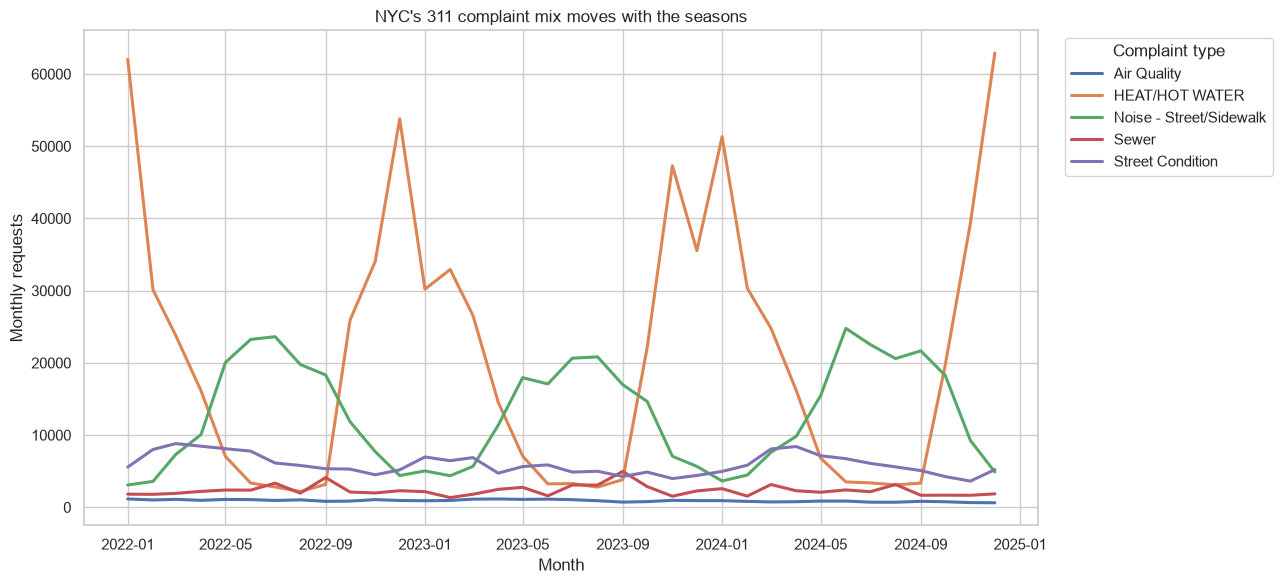

In [26]:
monthly_type = (
    daily_type.assign(month=daily_type["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "complaint_type"], as_index=False)["request_count"]
    .sum()
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.lineplot(
    data=monthly_type,
    x="month",
    y="request_count",
    hue="complaint_type",
    linewidth=2.2,
    ax=ax,
)
ax.set(
    title="NYC's 311 complaint mix moves with the seasons",
    xlabel="Month",
    ylabel="Monthly requests",
)
ax.legend(title="Complaint type", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "monthly_complaint_patterns.png", dpi=160, bbox_inches="tight")
plt.show()

**How to read:** Each line follows one complaint type by month. Peaks show when that issue puts more demand on 311.  
**What it shows:** Heat and hot water requests are highest in cold months. Street noise requests rise in warm months. The same pattern appears in all three years.

### Visual 2: Temperature pushes two complaint types in opposite directions

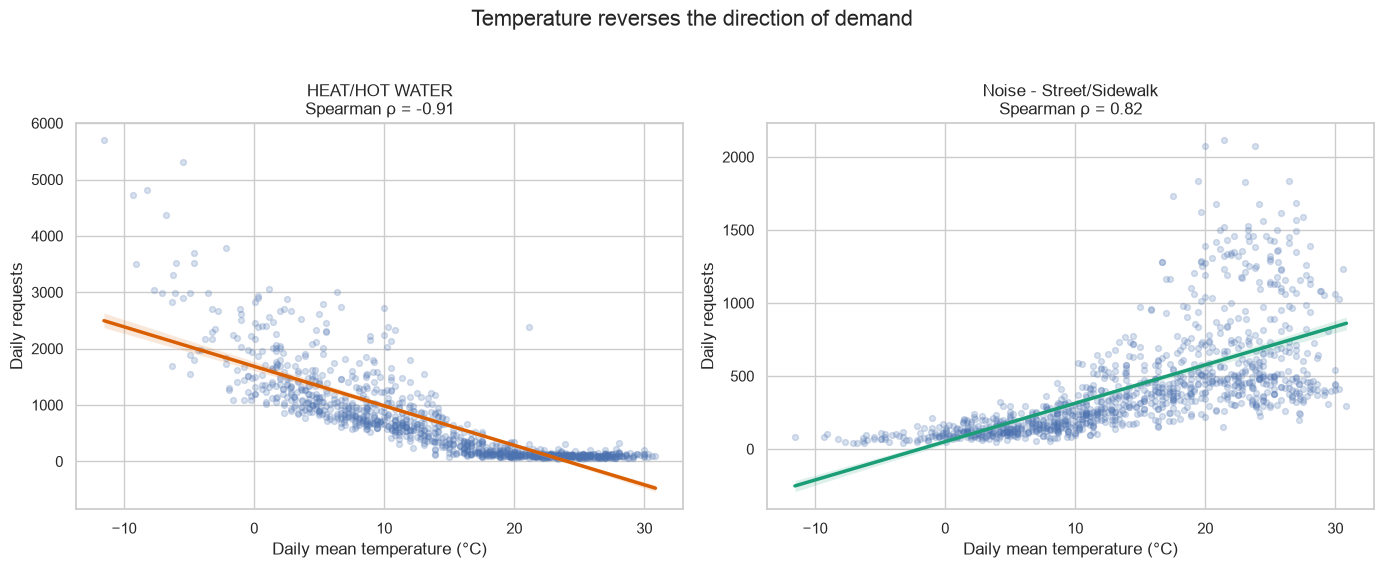

In [27]:
temperature_focus = daily_type[
    daily_type["complaint_type"].isin(["HEAT/HOT WATER", "Noise - Street/Sidewalk"])
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, complaint, color in zip(
    axes,
    ["HEAT/HOT WATER", "Noise - Street/Sidewalk"],
    ["#d95f02", "#1b9e77"],
):
    subset = temperature_focus[temperature_focus["complaint_type"].eq(complaint)]
    rho = correlations.loc[complaint]
    sns.regplot(
        data=subset,
        x="temp_mean_c",
        y="request_count",
        scatter_kws={"alpha": 0.22, "s": 18},
        line_kws={"color": color, "linewidth": 2.5},
        seed=42,
        ax=ax,
    )
    ax.set(
        title=f"{complaint}\nSpearman ρ = {rho:.2f}",
        xlabel="Daily mean temperature (°C)",
        ylabel="Daily requests",
    )

fig.suptitle("Temperature reverses the direction of demand", y=1.03, fontsize=16)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "temperature_complaint_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

**How to read:** Each dot is one day. The line shows the direction of the pattern. Spearman's ρ shows how strong the pattern is.  
**What it shows:** Heat and hot water complaints fall as temperature rises. The relationship is very strong at ρ = **−0.91**. Street noise complaints rise with temperature at ρ = **0.82**. Weather changes the type of help that residents request.

### Visual 3: Heavy rain is linked to sewer complaints

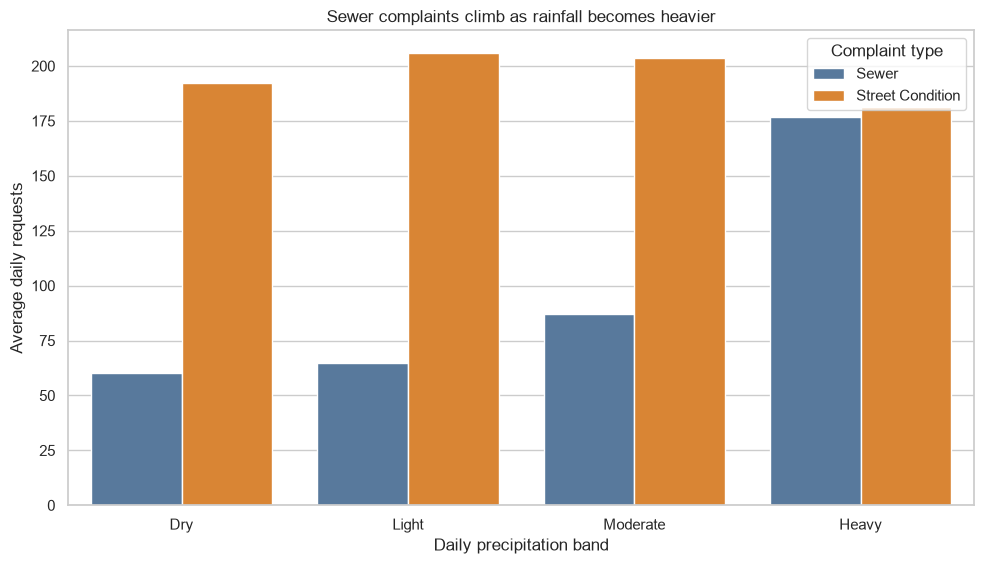

complaint_type,Sewer,Street Condition
rain_band,,
Dry,60.00,192.10
Light,64.60,205.90
Moderate,87.00,203.70
Heavy,176.60,181.40


In [28]:
rain_bins = [-0.01, 0, 2.5, 10, np.inf]
rain_labels = ["Dry", "Light", "Moderate", "Heavy"]
daily_type["rain_band"] = pd.cut(
    daily_type["prcp_mm"], bins=rain_bins, labels=rain_labels, include_lowest=True
)

rain_focus = (
    daily_type[daily_type["complaint_type"].isin(["Sewer", "Street Condition"])]
    .groupby(["rain_band", "complaint_type"], observed=True, as_index=False)["request_count"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5.8))
sns.barplot(
    data=rain_focus,
    x="rain_band",
    y="request_count",
    hue="complaint_type",
    palette=["#4c78a8", "#f58518"],
    errorbar=None,
    ax=ax,
)
ax.set(
    title="Sewer complaints climb as rainfall becomes heavier",
    xlabel="Daily precipitation band",
    ylabel="Average daily requests",
)
ax.legend(title="Complaint type")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rainfall_infrastructure_complaints.png", dpi=160, bbox_inches="tight")
plt.show()

rain_table = rain_focus.pivot(index="rain_band", columns="complaint_type", values="request_count")
rain_table.round(1)

In [29]:
# Estimate the uncertainty around the heavy rain and dry day sewer ratio.
sewer_daily = daily_type[daily_type["complaint_type"].eq("Sewer")]
dry_sewer = sewer_daily.loc[sewer_daily["rain_band"].eq("Dry"), "request_count"].to_numpy()
heavy_sewer = sewer_daily.loc[sewer_daily["rain_band"].eq("Heavy"), "request_count"].to_numpy()

rng = np.random.default_rng(42)
bootstrap_ratios = np.array(
    [
        rng.choice(heavy_sewer, len(heavy_sewer), replace=True).mean()
        / rng.choice(dry_sewer, len(dry_sewer), replace=True).mean()
        for _ in range(5000)
    ]
)
observed_ratio = heavy_sewer.mean() / dry_sewer.mean()
ci_low, ci_high = np.quantile(bootstrap_ratios, [0.025, 0.975])
print(f"Heavy-rain / dry-day sewer ratio: {observed_ratio:.2f}x")
print(f"Bootstrap 95% interval: {ci_low:.2f}x to {ci_high:.2f}x")

Heavy-rain / dry-day sewer ratio: 2.94x
Bootstrap 95% interval: 2.37x to 3.71x


**How to read:** Bar height shows the average requests in each rain group. The bootstrap check repeats the comparison with new samples. This shows how stable the result is.  
**What it shows:** Heavy rain days average **176.6 sewer requests**. Dry days average **60.0 requests**. Heavy rain days have about **2.9 times as many**. Street condition complaints do not show the same steady rise.

### Visual 4: Every borough responds strongly to the cold

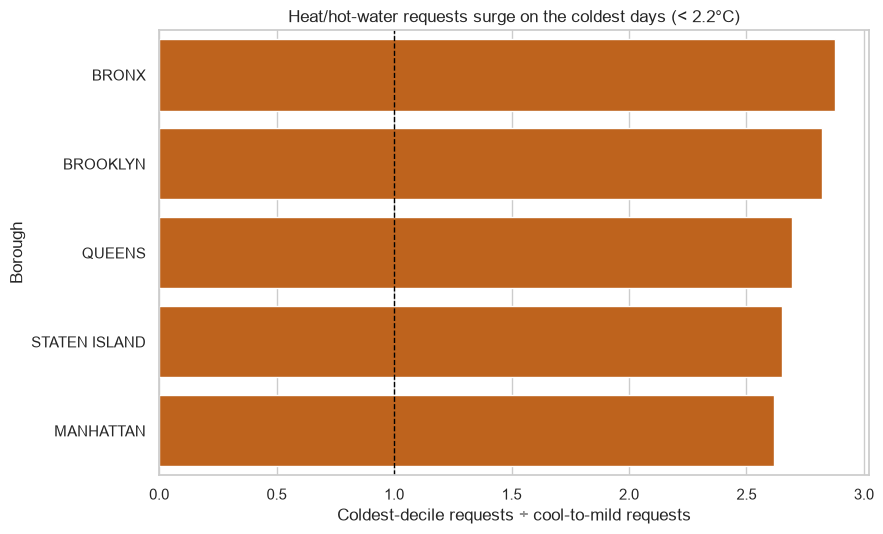

temperature_band,Coldest 10%,Cool to mild,Warm,cold_vs_mild_ratio
borough,,,,
BRONX,783.95,272.30,38.64,2.88
BROOKLYN,561.11,198.90,30.01,2.82
QUEENS,282.39,104.87,14.35,2.69
STATEN ISLAND,23.97,9.04,2.41,2.65
MANHATTAN,459.36,175.46,28.35,2.62


In [30]:
heat_borough = combined[combined["complaint_type"].eq("HEAT/HOT WATER")].copy()
daily_heat_borough = heat_borough.groupby(["date", "borough"], as_index=False).agg(
    request_count=("request_count", "sum"),
    temp_mean_c=("temp_mean_c", "first"),
)

cold_cutoff = weather_analysis["temp_mean_c"].quantile(0.10)
daily_heat_borough["temperature_band"] = pd.cut(
    daily_heat_borough["temp_mean_c"],
    bins=[-np.inf, cold_cutoff, 20, np.inf],
    labels=["Coldest 10%", "Cool to mild", "Warm"],
)

borough_response = daily_heat_borough.pivot_table(
    index="borough",
    columns="temperature_band",
    values="request_count",
    aggfunc="mean",
    observed=True,
)
borough_response["cold_vs_mild_ratio"] = (
    borough_response["Coldest 10%"] / borough_response["Cool to mild"]
)
borough_response = borough_response.sort_values("cold_vs_mild_ratio", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=borough_response.reset_index(),
    y="borough",
    x="cold_vs_mild_ratio",
    color="#d95f02",
    errorbar=None,
    ax=ax,
)
ax.axvline(1, color="black", linestyle="--", linewidth=1)
ax.set(
    title=f"Heat/hot-water requests surge on the coldest days (< {cold_cutoff:.1f}°C)",
    xlabel="Coldest-decile requests ÷ cool-to-mild requests",
    ylabel="Borough",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cold_weather_borough_response.png", dpi=160, bbox_inches="tight")
plt.show()

borough_response.round(2)

**How to read:** A value of 2 means twice as many heat and hot water complaints. It compares the coldest 10 percent of days with cool and mild days.  
**What it shows:** All five boroughs rise by about **2.6 to 2.9 times**. The Bronx has the largest increase at **2.88 times**. It also has the highest number of requests on cold days.

### Visual 5: The complaint mix changes by season

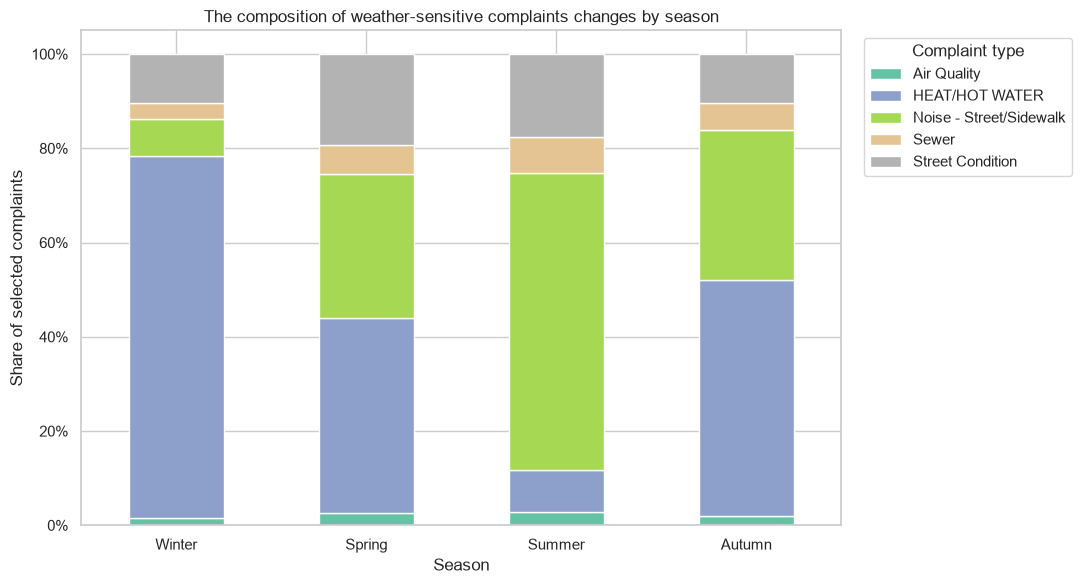

complaint_type,Air Quality,HEAT/HOT WATER,Noise - Street/Sidewalk,Sewer,Street Condition
season,,,,,
Winter,0.02,0.77,0.08,0.04,0.10
Spring,0.03,0.41,0.31,0.06,0.19
Summer,0.03,0.09,0.63,0.08,0.18
Autumn,0.02,0.50,0.32,0.06,0.10


In [31]:
season_lookup = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}
season_order = ["Winter", "Spring", "Summer", "Autumn"]
seasonal_mix = (
    daily_type.assign(season=daily_type["date"].dt.month.map(season_lookup))
    .pivot_table(index="season", columns="complaint_type", values="request_count", aggfunc="sum")
    .reindex(season_order)
)
seasonal_share = seasonal_mix.div(seasonal_mix.sum(axis=1), axis=0)

ax = seasonal_share.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Set2",
)
ax.set(
    title="The composition of weather-sensitive complaints changes by season",
    xlabel="Season",
    ylabel="Share of selected complaints",
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(title="Complaint type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "seasonal_complaint_mix.png", dpi=160, bbox_inches="tight")
plt.show()

seasonal_share.round(3)

**How to read:** Each bar is one season and adds to 100 percent. Larger sections mean a larger share of complaints.  
**What it shows:** Heat and hot water issues make up **76.8 percent** of the selected winter complaints. They make up only **9.0 percent** in summer. Weather changes both the number and type of requests.

### Answer

Weather has a clear link with NYC 311 demand. Cold days bring more heat and hot water complaints. Warm days bring more street noise complaints. Heavy rain brings almost three times as many sewer complaints as dry days. The same cold weather pattern appears in every borough. The Bronx has the highest volume and the strongest increase.

These are observational relationships, not proof that weather alone caused every request. Still, the consistency across 1,096 days, multiple complaint types, and every borough makes the patterns useful for anticipating service pressure.

### 5.2 Reflection

A future version could add weather stations in the outer boroughs. Borough counts could also be adjusted for population and housing stock. Agency response times and delayed weather effects would add another useful view of service pressure.

## Reproducibility notes

* The analysis window is fixed at 2022 to 2024. This keeps the results stable.
* Raw and cleaned data are stored separately.
* The API query, cleaning steps, checks, bootstrap seed, and chart code are included.
* Source flags and units are kept or explained.